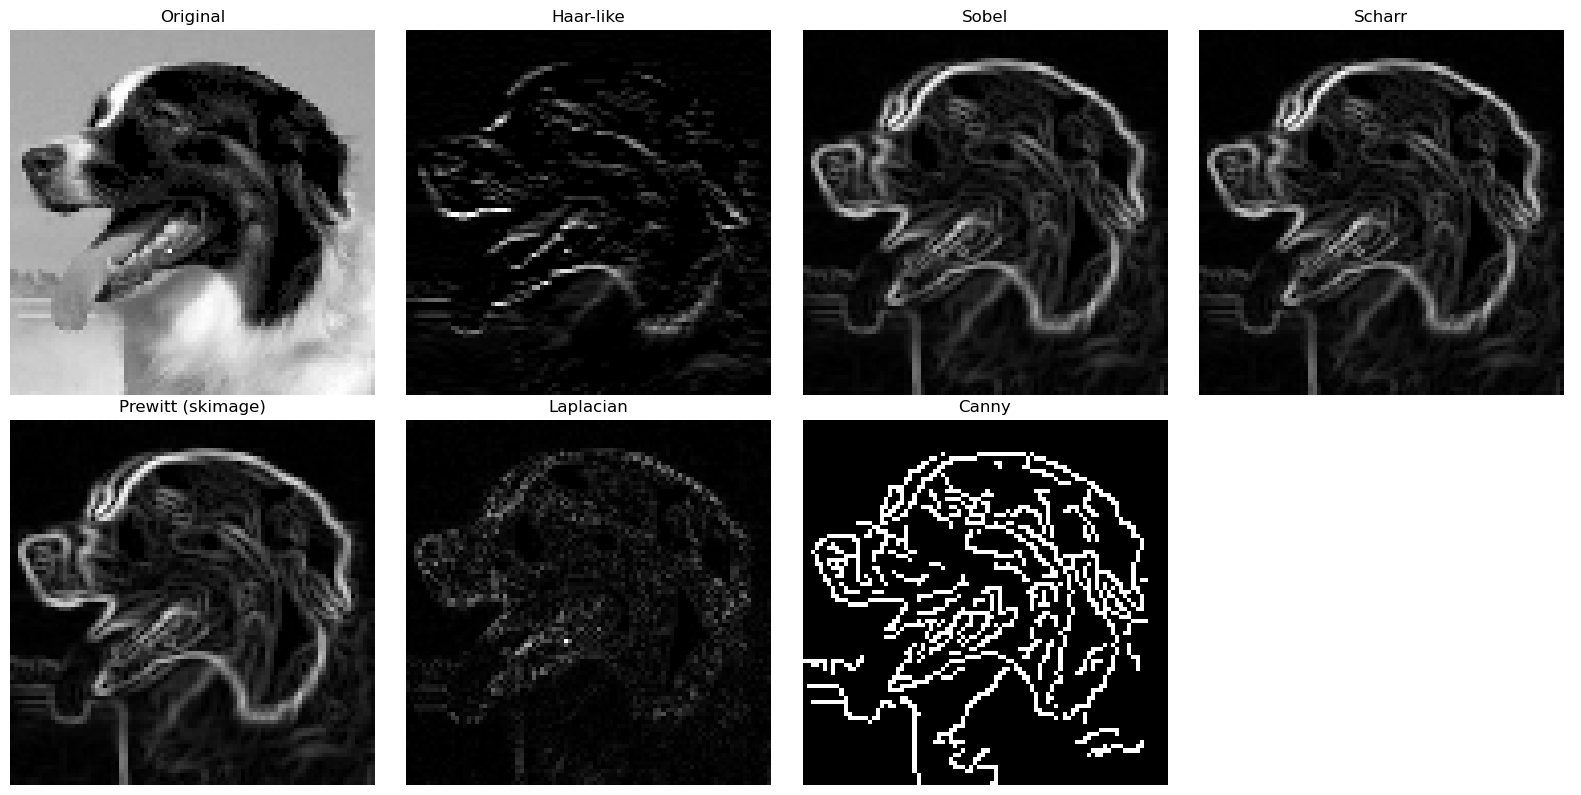

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from skimage.filters import prewitt

# 1. Download an image from the internet
url = 'https://upload.wikimedia.org/wikipedia/commons/7/7d/Dog_face.png'
headers = {'User-Agent': 'Mozilla/5.0'}  # Add headers for some servers

response = requests.get(url, headers=headers)
img_array = np.frombuffer(response.content, np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError('Image download or decode failed. Check the URL or your internet connection.')

# 2. Apply edge detection filters

# Haar-like (simple horizontal edge) kernel
haar_kernel = np.array([[-1, -1], [1, 1]])
haar = cv2.filter2D(img, -1, haar_kernel)

# Sobel
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.hypot(sobelx, sobely)

# Scharr
scharrx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
scharry = cv2.Scharr(img, cv2.CV_64F, 0, 1)
scharr = np.hypot(scharrx, scharry)

# Prewitt
prewitt_edges = prewitt(img)

# Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# Canny
canny = cv2.Canny(img, 100, 200)

# 3. Plot the results
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(np.abs(haar), cmap='gray')
axes[1].set_title('Haar-like')
axes[1].axis('off')

axes[2].imshow(sobel, cmap='gray')
axes[2].set_title('Sobel')
axes[2].axis('off')

axes[3].imshow(scharr, cmap='gray')
axes[3].set_title('Scharr')
axes[3].axis('off')

axes[4].imshow(prewitt_edges, cmap='gray')
axes[4].set_title('Prewitt (skimage)')
axes[4].axis('off')

axes[5].imshow(np.abs(laplacian), cmap='gray')
axes[5].set_title('Laplacian')
axes[5].axis('off')

axes[6].imshow(canny, cmap='gray')
axes[6].set_title('Canny')
axes[6].axis('off')

axes[7].axis('off')  # Empty subplot

plt.tight_layout()
plt.show()
